# Import the model and dataset


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from src.models.models import ProteinBindingGNN
from src.models.loss import FocalLoss
from src.models.loaders import make_loaders
from src.loggers.metrics import compute_metrics
from src.visualize.graph_utils import create_wandb_point_cloud
from src.visualize.graph_utils import create_wandb_comparison_table, add_to_wandb_comparison_table
import wandb, weave
import numpy as np
import os
import pandas as pd
from dotenv import load_dotenv
import os
from pathlib import Path

load_dotenv()
wandb_api_key = os.getenv("WANDB_API_KEY")


: 

Hola


In [2]:
df = pd.read_csv("data/training_split_final.csv")
dataset_dir = Path("data/dataset")
pdb_dir = Path("data/pdb_test")
loaders = make_loaders(df, dataset_dir, pdb_dir, batch_size=16, num_workers=4, pin_memory= False)

train_loader = loaders["train_loader"]
val_loader   = loaders["val_loader"]
val_dataset  = loaders["val_dataset"]


NameError: name 'pd' is not defined

In [104]:
import pandas as pd
import torch

# ── 1. Load CSV ────────────────────────────────────────────────────────
df = pd.read_csv("data/training_split_final.csv")
print(df["split"].value_counts())
print(df.head())

# ── 2. Make loaders ────────────────────────────────────────────────────
loaders = make_loaders(df, dataset_dir=Path("data/dataset"), pdb_dir=Path("data/pdb_test"), batch_size= 16, num_workers=0)  # num_workers=0 for debugging
train_loader = loaders["train_loader"]
val_loader   = loaders["val_loader"]
val_dataset  = loaders["val_dataset"]

# ── 3. Check one train batch ───────────────────────────────────────────
batch = next(iter(train_loader))
print("\n── Train batch ──")
print(f"  x          : {batch.x.shape}")           # (total_nodes, 1304)
print(f"  pos        : {batch.pos.shape}")          # (total_nodes, 3)
print(f"  edge_index : {batch.edge_index.shape}")   # (2, total_edges)
print(f"  edge_attr  : {batch.edge_attr.shape}")    # (total_edges, 4)
print(f"  y          : {batch.y.shape}")            # (total_nodes,)
print(f"  batch      : {batch.batch.shape}")        # (total_nodes,) — graph membership
print(f"  n_graphs   : {batch.num_graphs}")         # should be 4

# ── 4. Check one val batch ─────────────────────────────────────────────
batch = next(iter(val_loader))
print("\n── Val batch ──")
print(f"  x          : {batch.x.shape}")
print(f"  y          : {batch.y.shape}")
print(f"  n_graphs   : {batch.num_graphs}")

# ── 5. Check binding label distribution ───────────────────────────────
print("\n── Label distribution in val batch ──")
print(f"  binding     : {batch.y.sum().item():.0f}")
print(f"  non-binding : {(batch.y == 0).sum().item():.0f}")
print(f"  ratio       : {batch.y.mean().item():.3f}")

# ── 6. Check val visualization samples ────────────────────────────────
samples = get_val_samples(val_dataset, n=5, seed=0)
print(f"\n── Val samples for W&B ({len(samples)} found) ──")
for s in samples:
    print(f"  {s['pdb_id']:20s}  nodes={s['graph'].num_nodes}  "
          f"binding={s['y_true'].sum():.0f}  pdb={s['pdb_path']}")

# ── 7. Confirm sizes are grouped within batches (sorted sampler check) ─
print("\n── Batch size variance check (should be low) ──")
sizes = []
for i, batch in enumerate(train_loader):
    # num_nodes per graph in this batch
    counts = torch.bincount(batch.batch)
    sizes.append(counts.float().std().item())
    if i >= 10:
        break
print(f"  avg std of n_residues within a batch: {sum(sizes)/len(sizes):.1f}")
print("  (lower = better grouping from SortedBatchSampler)")


── Train batch ──
  x          : torch.Size([5652, 1305])
  pos        : torch.Size([5652, 3])
  edge_index : torch.Size([2, 82672])
  edge_attr  : torch.Size([82672, 4])
  y          : torch.Size([5652])
  batch      : torch.Size([5652])
  n_graphs   : 16

── Val batch ──
  x          : torch.Size([4347, 1305])
  y          : torch.Size([4347])
  n_graphs   : 16

── Label distribution in val batch ──
  binding     : 194
  non-binding : 4153
  ratio       : 0.045

── Val samples for W&B (5 found) ──
  1unq_A                nodes=117  binding=9  pdb=data/pdb_test/1unq_A.pdb
  1f0x_B                nodes=502  binding=24  pdb=data/pdb_test/1f0x_B.pdb
  6nic_C                nodes=358  binding=7  pdb=data/pdb_test/6nic_C.pdb
  6u0j_A                nodes=309  binding=8  pdb=data/pdb_test/6u0j_A.pdb
  3ku0_A                nodes=251  binding=7  pdb=data/pdb_test/3ku0_A.pdb

── Batch size variance check (should be low) ──
  avg std of n_residues within a batch: 144.6
  (lower = better group

In [88]:
samples = get_val_samples(val_dataset, n=5, seed=1)


In [89]:
samples

[{'pdb_id': '1f0x_B',
  'pdb_path': 'data/pdb_test/1f0x_B.pdb',
  'graph': Data(x=[502, 1305], edge_index=[2, 7544], edge_attr=[7544, 4], y=[502], pos=[502, 3], num_nodes=502, pdb_id='1f0x_B'),
  'y_true': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1.,
         1., 1., 1., 1., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.,
         0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 1., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0

In [32]:
df = pd.read_csv("data/manifest_full.csv")


In [33]:
print(f"Before: {df['split'].value_counts().to_dict()}")


Before: {'training': 6962, 'testing': 1738}


In [ ]:
df = df.drop(columns=["split", "cv_batch"], errors="ignore")


In [38]:
# Re-run split on the full 8500 pool
df = create_split(
    df,
    n_folds    = 5,
    test_frac  = 0.10,   # 850 test instead of 1738
    seed       = 42,
)

print(f"After: {df['split'].value_counts().to_dict()}")
# After: {'training': 7650, 'testing': 850}

save_split_csv(df, "split_final.csv")

After: {'training': 7832, 'testing': 868}
Saved split to split_final.csv

  Total graphs : 8700
  Test         : 868 (10.0%)
  Training     : 7832 (90.0%)

  CV folds (training only):
    Fold 1: train=6265 | val=1567
    Fold 2: train=6265 | val=1567
    Fold 3: train=6266 | val=1566
    Fold 4: train=6266 | val=1566
    Fold 5: train=6266 | val=1566



In [42]:
df.to_csv("data/train_test_split.csv", index=False)

In [26]:
print(data.head())

  pdb_id chain     split  cv_batch  n_residues  n_binding
0   4lzj     B  training         2         299         10
1   4m1j     C   testing         0         548          7
2   4m20     A  training         3         121         11
3   4m25     A  training         4         336          9
4   4m2m     A  training         5         380          9


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from src.models.models import ProteinBindingGNN
from src.models.loss import FocalLoss
from src.loggers.metrics import compute_metrics
from src.visualize.graph_utils import create_wandb_point_cloud
from src.visualize.graph_utils import create_wandb_comparison_table, add_to_wandb_comparison_table
import wandb, weave
import os
from dotenv import load_dotenv
import os

load_dotenv()
wandb_api_key = os.getenv("WANDB_API_KEY")

/opt/miniconda3/envs/pytorch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="a01700257",
    # Set the wandb project where this run will be logged.
    project="Graph_binding",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 0.02,
        "architecture": "CNN",
        "dataset": "CIFAR-100",
        "epochs": 10,
    },
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: a01700257 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Initializing weave.
weave: Logged in as Weights & Biases user: a01700257.
weave: View Weave data at https://wandb.ai/a01700257/Graph_binding/weave


In [ ]:
data = torch.load("data/preprocessed/test/4pz2_A.pt", map_location=torch.device('cpu'), weights_only= False)

In [4]:
loss_fn = FocalLoss(alpha=0.25, gamma=2.0)


In [5]:
model = ProteinBindingGNN(num_egnn_layers=3, num_evoformer_blocks=4, num_heads=8, dropout=0.1, update_coords=True, num_recycles=3, alpha=0.3)

'''
        node_input_dim: int = 1305,   # ESM2(1280) + one-hot(20) + biochem(5)
        edge_input_dim: int = 4,       # weight, type, contact, coulomb
        hidden_dim: int = 256,         # H
        num_egnn_layers: int = 3,      # Number of equivariant layers
        num_evoformer_blocks: int = 4, # Number of attention blocks
        num_heads: int = 8,            # Attention heads
        dropout: float = 0.1,
        update_coords: bool = True,    # Whether to update 3D positions
        num_recycles: int = 3,        # R — how many Evoformer refinement passes
        alpha: float = 0.3,           # Learnable recycling weight (initial value
'''
;

''

In [6]:
(data.y == 1).sum()

tensor(21)

In [9]:
data

Data(x=[572, 1305], edge_index=[2, 8290], edge_attr=[8290, 4], y=[572], pos=[572, 3], num_nodes=572)

In [7]:
y_true = data.y
y_pred = model.predict(data)
pdb_path = "data/4lq9_A.pdb"

In [8]:
y_true = data.y
y_pred = model.predict(data)
pdb_path = "data/4lq9_A.pdb"

# With predictions

# First protein creates the table
table = create_wandb_comparison_table(pdb_path, 1, y_true, y_pred, include_molecules = True) 
add_to_wandb_comparison_table(table, pdb_path,1, y_true, y_pred)
wandb.log({"all_predictions": table})


FileNotFoundError: [Errno 2] No such file or directory: 'data/4lq9_A.pdb'

In [9]:
from src.visualize.graph_utils import compare_binding_predictions

compare_binding_predictions(pdb_path, y_true, y_pred, threshold=0.5)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [4]:
data = torch.load("data/12as_B.pt", map_location=torch.device('cpu'), weights_only= False)

In [36]:
data

Data(x=[327, 1305], edge_index=[2, 4722], edge_attr=[4722, 4], y=[327], pos=[327, 3], num_nodes=327)

In [10]:
model = ProteinBindingGNN(num_egnn_layers=3, num_evoformer_blocks=4)

'''
        node_input_dim: int = 1305,   # ESM2(1280) + one-hot(20) + biochem(5)
        edge_input_dim: int = 4,       # weight, type, contact, coulomb
        hidden_dim: int = 256,         # H
        num_egnn_layers: int = 3,      # Number of equivariant layers
        num_evoformer_blocks: int = 4, # Number of attention blocks
        num_heads: int = 8,            # Attention heads
        dropout: float = 0.1,
        update_coords: bool = True,    # Whether to update 3D positions
'''

'\n        node_input_dim: int = 1305,   # ESM2(1280) + one-hot(20) + biochem(5)\n        edge_input_dim: int = 4,       # weight, type, contact, coulomb\n        hidden_dim: int = 256,         # H\n        num_egnn_layers: int = 3,      # Number of equivariant layers\n        num_evoformer_blocks: int = 4, # Number of attention blocks\n        num_heads: int = 8,            # Attention heads\n        dropout: float = 0.1,\n        update_coords: bool = True,    # Whether to update 3D positions\n'

In [11]:
sum(p.numel() for p in model.parameters())

7222561

In [6]:
from src.visualize.graph_utils import edge_to_dense, backbone_graph, visualize_graph

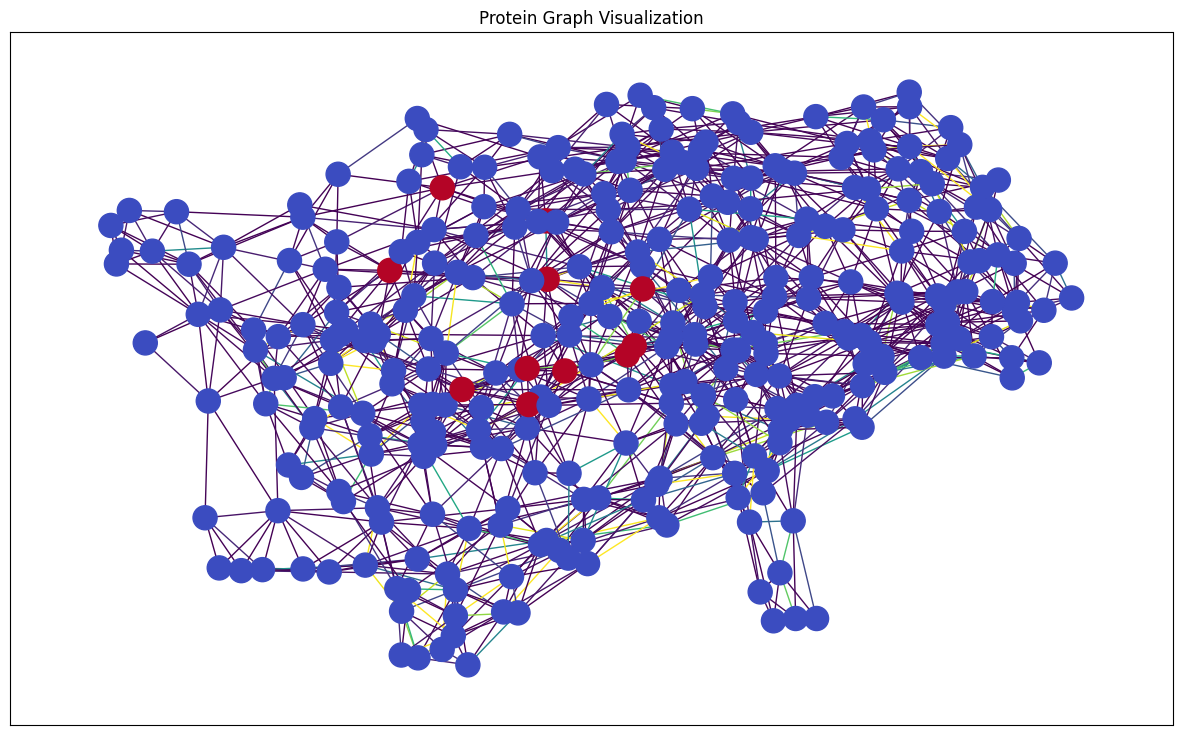

In [7]:
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True, edge_attrs=["edge_attr"])
visualize_graph(G, color=data.y)

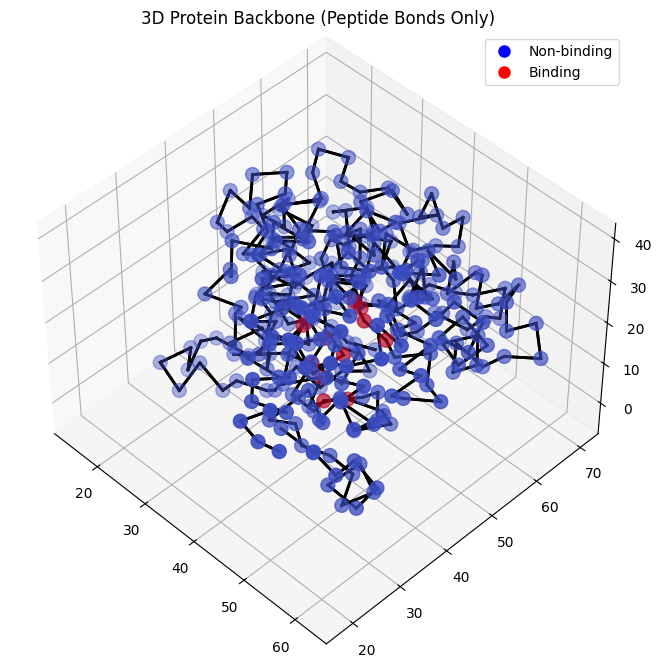

In [5]:
backbone_graph(data)

In [2]:
import torch
import torch_geometric

/opt/miniconda3/envs/pytorch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
run.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.
